# 05: Stability

*How robust is the KG's predictive signal under edge loss?*

This notebook evaluates **stability** across all loaded KGs. Network robustness quantifies how well Adamic-Adar entity-pair rankings are preserved under systematic edge removal — a proxy for resilience to the inherent incompleteness of real-world KGs. If predictive signal is well-distributed across the graph, rankings should be largely preserved even after substantial edge removal. Fragile rankings indicate over-reliance on a sparse set of structurally critical edges.

| Metric | Definition | Quantification | Scoring |
|--------|-----------|----------------|---------|
| **Random-dropout stability** | Preservation of Adamic-Adar rankings under uniform random edge removal | Spearman *r* at each dropout rate (5%, 10%, 20%) reported to show degradation profile; **10% is the pre-specified primary operating point** | CLES: (*r*₁₀ + 1) / 2 at 10% dropout |
| **Periphery-dropout stability** | Same, but edges incident to lowest-degree nodes removed first (static ordering) | Spearman *r* at each dropout rate (5%, 10%, 20%); **10% is the pre-specified primary operating point** | CLES: (*r*₁₀ + 1) / 2 at 10% dropout |

**Primary operating point.** 10% edge dropout is pre-specified as the primary reporting point, representing a moderate incompleteness regime consistent with estimates of missing edges in published biomedical KGs (Paulheim, 2017). The full degradation curve across 5%, 10%, and 20% is shown in the stability figure and exported to `results/stability/stability.csv`.

**Additional metric.** Top-K overlap (K = 100) is computed for characterisation but does not enter the dimension score.

**Thresholds** (interpretive, not used in scoring): Spearman *r* > 0.95 at 10% random dropout = high stability; *r* < 0.85 = fragile topology.

**Inputs:** `config.yaml` · KG edge/node files (via `load_kg`)

**Outputs:** `results/figures/05_stability.{pdf,png}` · `results/stability/stability.csv` · `results/checkpoints/05_stability.pkl`

**Dependencies:** `src/loading.py` · `src/graph_utils.py` · `src/scoring.py` · `src/plotting.py`

## Set-up

In [1]:
# Imports
import sys, os, warnings, math, pickle
warnings.filterwarnings('ignore')
from pathlib import Path

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from scipy import stats

from src.plotting    import setup_style, clean_ax, save_fig, panel_label, TEXT_COLOR, OI_SKY_BLUE, KG_PALETTE
from src.loading     import find_config, load_config, load_kg
from src.graph_utils import build_graph, build_lookup_maps
from src.scoring     import score_adamic_adar

setup_style()

In [2]:
# Config and paths
config  = load_config(find_config(_root))
params  = config['analysis_params']
BASE    = config['_base_dir']
FIGS    = BASE / 'results' / 'figures';   FIGS.mkdir(parents=True, exist_ok=True)
RESULTS = BASE / 'results' / 'stability'; RESULTS.mkdir(parents=True, exist_ok=True)

# Spine styling helper (used in stability plots)
PANEL_SPINE_STYLE = {'lw': 1.4, 'color': TEXT_COLOR}

def _style_left_spine(ax) -> None:
    '''Keep only left spine visible with house style.'''
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].update(PANEL_SPINE_STYLE)

In [3]:
# Load KGs
KG_NAMES  = list(config['knowledge_graphs'].keys())
KG_COLORS = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}

kgs, graphs, maps = {}, {}, {}
for name in KG_NAMES:
    try:
        kg, nodes    = load_kg(name, config)
        G            = build_graph(kg, nodes)
        kgs[name]    = {'kg': kg, 'nodes': nodes}
        graphs[name] = G
        maps[name]   = build_lookup_maps(nodes)
        print(f'{name:12s}: {G.number_of_nodes():>8,} nodes  {G.number_of_edges():>10,} edges')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND]')
    except Exception as e:
        print(f'{name:12s}: [ERROR] {e}')

LOADED = [n for n in KG_NAMES if n in graphs and config['knowledge_graphs'].get(n, {}).get('relations')]
print(f'\nLoaded: {LOADED}')

primekg     :  129,375 nodes   4,049,642 edges
hetionet    :   47,031 nodes   2,107,709 edges
drkg        :   97,238 nodes   4,400,766 edges
openbilink  :  185,929 nodes   3,200,327 edges
biokg       :  105,524 nodes   2,043,846 edges

Loaded: ['primekg', 'hetionet', 'drkg', 'openbilink', 'biokg']


## Therapeutic pair extraction

Stability is measured over Adamic-Adar rankings of known therapeutic (drug–disease) pairs versus random pairs. This requires extracting the therapeutic pairs for each KG.

In [4]:
# Entity type sets and LCC computation
DRUG_TYPES    = {'drug', 'Compound', 'compound', 'Drug'}  # 'Drug' for OpenBioLink
DISEASE_TYPES = {'disease', 'Disease'}

lcc_sets = {
    name: sorted(nx.connected_components(graphs[name]), key=len, reverse=True)[0]
    for name in LOADED
}

In [5]:
# Therapeutic pair config - relation filters per KG
KG_THERAPEUTIC = {
    'primekg':  {'mode': 'exact',   'relations': {'indication'}},
    'hetionet': {'mode': 'exact',   'relations': {'CtD'}},
    'drkg':       {'mode': 'pattern', 'pattern':   'treat|indication'},
    # OpenBioLink: DIS_DRUG is the sole drug-disease relation
    'openbilink': {'mode': 'exact',   'relations': {'DIS_DRUG'}},
    # BioKG: DRUG_DISEASE_ASSOCIATION is the therapeutic relation
    'biokg':      {'mode': 'exact',   'relations': {'DRUG_DISEASE_ASSOCIATION'}},
}

def _relation_mask(kg: pd.DataFrame, cfg: dict) -> pd.Series:
    if cfg['mode'] == 'exact':
        return kg['relation'].isin(cfg['relations'])
    if cfg['mode'] == 'pattern':
        mask = kg['relation'].str.lower().str.contains(cfg['pattern'], na=False)
        if 'x_type' in kg.columns:
            mask &= kg['x_type'].isin(DRUG_TYPES | DISEASE_TYPES)
        return mask
    raise ValueError(f'Unknown mode: {cfg["mode"]}')


def extract_therapeutic_pairs(name: str) -> list:
    cfg = KG_THERAPEUTIC.get(name)
    if cfg is None:
        return []
    kg, lcc = kgs[name]['kg'], lcc_sets[name]
    sub = (kg[_relation_mask(kg, cfg)][['x_index', 'y_index', 'x_type', 'y_type']]
           .astype({'x_index': int, 'y_index': int}))
    sub = sub[sub['x_index'].isin(lcc) & sub['y_index'].isin(lcc)]
    fwd = sub[sub['x_type'].isin(DRUG_TYPES) & sub['y_type'].isin(DISEASE_TYPES)]
    rev = sub[sub['y_type'].isin(DRUG_TYPES) & sub['x_type'].isin(DISEASE_TYPES)]
    return list(set(
        list(zip(fwd['x_index'], fwd['y_index'])) +
        list(zip(rev['y_index'], rev['x_index']))
    ))


def build_negative_pairs(name: str, pos_set: set, n_sample: int, rng) -> list:
    lcc           = lcc_sets[name]
    G             = graphs[name]
    drug_nodes    = [v for v in lcc if G.nodes[v].get('node_type') in DRUG_TYPES]
    disease_nodes = [v for v in lcc if G.nodes[v].get('node_type') in DISEASE_TYPES]
    if not drug_nodes or not disease_nodes:
        return []
    neg, attempts = [], 0
    while len(neg) < n_sample and attempts < n_sample * 20:
        d, dis = rng.choice(drug_nodes), rng.choice(disease_nodes)
        if (d, dis) not in pos_set and (dis, d) not in pos_set:
            neg.append((d, dis))
        attempts += 1
    return neg

In [6]:
# Extract therapeutic pairs
rng = np.random.RandomState(params.get('random_seed', 42))

therapeutic_pairs = {}
for name in LOADED:
    tp = extract_therapeutic_pairs(name)
    therapeutic_pairs[name] = tp
    print(f'{name:12s}: {len(tp):,} therapeutic pairs')

primekg     : 9,388 therapeutic pairs
hetionet    : 755 therapeutic pairs
drkg        : 4,968 therapeutic pairs
openbilink  : 7,164 therapeutic pairs
biokg       : 66,867 therapeutic pairs


## Stability analysis

Two perturbation strategies are applied at dropout rates drawn from `analysis_params.robustness.dropout_rates`:

| Strategy | Description |
|---|---|
| **Random** | Edges removed uniformly at random — baseline robustness |
| **Periphery** | Lowest-degree incident edges removed first — targets structurally fragile periphery |

Spearman *r* > 0.95 at 10 % dropout → high stability; *r* < 0.85 → fragile topology.

### Parameters & helpers

In [7]:
# Robustness parameters
_rob         = params.get('robustness', {})
DROPOUT_RATES = _rob.get('dropout_rates', [0.05, 0.10, 0.20])
SAMPLE_SIZE   = _rob.get('sample_size', 100)
TOP_K         = _rob.get('top_k', 100)
RANDOM_SEED   = params.get('random_seed', 42)

In [8]:
# Stability metric helpers
def _spearman(a: np.ndarray, b: np.ndarray) -> float:
    mask = (a > 0) | (b > 0)
    return stats.spearmanr(a[mask], b[mask]).statistic if mask.sum() > 10 else np.nan

def _top_k_overlap(a: np.ndarray, b: np.ndarray, k: int = TOP_K) -> float:
    return len(set(np.argsort(-a)[:k]) & set(np.argsort(-b)[:k])) / k

def _metrics(G_pert, baseline: np.ndarray, pairs: list) -> tuple:
    pert = np.array(score_adamic_adar(G_pert, pairs))
    return _spearman(baseline, pert), _top_k_overlap(baseline, pert)



### Robustness sweep

In [9]:
# Dropout robustness analysis
stab_results = {}

for name in LOADED:
    tp = therapeutic_pairs.get(name)
    if not tp:
        print(f'{name}: no therapeutic pairs, skipping')
        continue

    G          = graphs[name]
    pos_set    = set(tp)
    all_edges  = list(G.edges())
    stab_rng   = np.random.RandomState(RANDOM_SEED)

    pos_sample = [tp[i] for i in stab_rng.choice(len(tp), min(SAMPLE_SIZE, len(tp)), replace=False)]
    neg_sample = build_negative_pairs(name, pos_set, len(pos_sample), stab_rng)
    all_pairs  = pos_sample + neg_sample
    baseline   = np.array(score_adamic_adar(G, all_pairs))

    deg          = dict(G.degree())
    sorted_edges = sorted(all_edges, key=lambda e: min(deg[e[0]], deg[e[1]]))

    print(f'{name}: {len(pos_sample)} pos + {len(neg_sample)} neg | {len(all_edges):,} edges')

    res = {}
    for rate in DROPOUT_RATES:
        n_drop = int(len(all_edges) * rate)

        G_rand = G.copy()
        G_rand.remove_edges_from([all_edges[i]
                                   for i in stab_rng.choice(len(all_edges), n_drop, replace=False)])

        G_periph = G.copy()
        G_periph.remove_edges_from(sorted_edges[:n_drop])

        res[rate] = {
            'random':     dict(zip(['spearman_r', 'top_k'], _metrics(G_rand,   baseline, all_pairs))),
            'periphery':  dict(zip(['spearman_r', 'top_k'], _metrics(G_periph, baseline, all_pairs))),
        }
        print(f'  {rate:.0%}  '
              f'rand r={res[rate]["random"]["spearman_r"]:.3f}  '
              f'periph r={res[rate]["periphery"]["spearman_r"]:.3f}')

    stab_results[name] = res
    print()

primekg: 500 pos + 500 neg | 4,049,642 edges
  5%  rand r=0.996  periph r=0.991
  10%  rand r=0.993  periph r=0.915
  15%  rand r=0.987  periph r=0.839
  20%  rand r=0.978  periph r=0.725
  25%  rand r=0.971  periph r=0.653
  30%  rand r=0.964  periph r=0.617

hetionet: 500 pos + 500 neg | 2,107,709 edges
  5%  rand r=0.991  periph r=0.990
  10%  rand r=0.977  periph r=0.968
  15%  rand r=0.961  periph r=0.955
  20%  rand r=0.937  periph r=0.929
  25%  rand r=0.933  periph r=0.909
  30%  rand r=0.889  periph r=0.878

drkg: 500 pos + 500 neg | 4,400,766 edges
  5%  rand r=0.996  periph r=0.926
  10%  rand r=0.990  periph r=0.837
  15%  rand r=0.987  periph r=0.800
  20%  rand r=0.978  periph r=0.749
  25%  rand r=0.970  periph r=0.730
  30%  rand r=0.967  periph r=0.732

openbilink: 500 pos + 500 neg | 3,200,327 edges
  5%  rand r=0.914  periph r=0.959
  10%  rand r=0.866  periph r=0.712
  15%  rand r=0.780  periph r=0.488
  20%  rand r=0.727  periph r=0.416
  25%  rand r=0.673  periph 

### Visualisation & export

  → Saved: 05_stability.pdf / .png


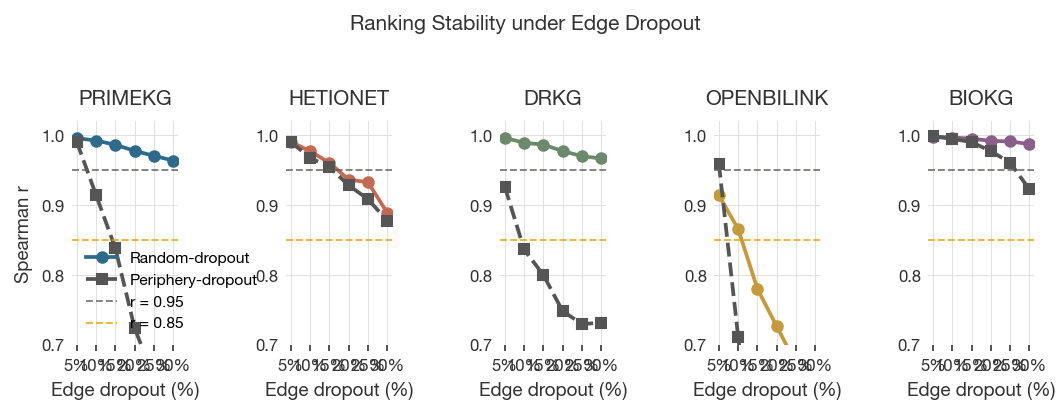

In [10]:
# Ranking stability under edge dropout
STRATEGIES = {
    'random':     ('Random-dropout',   'o-',  None),
    'periphery':  ('Periphery-dropout', 's--', '#555555'),
}

avail_stab   = [n for n in LOADED if n in stab_results]
dropout_pcts = [r * 100 for r in DROPOUT_RATES]

fig, axes = plt.subplots(1, len(avail_stab), figsize=(7.2, 2.6))
if len(avail_stab) == 1:
    axes = [axes]

for ax, name in zip(axes, avail_stab):
    res = stab_results[name]
    for strategy, (label, style, color) in STRATEGIES.items():
        col   = color or KG_COLORS[name]
        means = [res[r][strategy]['spearman_r'] for r in DROPOUT_RATES]
        ax.plot(dropout_pcts, means, style, color=col, lw=1.8, ms=5, label=label)

    ax.axhline(0.95, color='#655F55', ls='--', lw=0.9, alpha=0.8, label='r = 0.95')
    ax.axhline(0.85, color='#E69F00', ls='--', lw=0.9, alpha=0.8, label='r = 0.85')
    ax.set_xticks(dropout_pcts)
    ax.set_xticklabels([f'{p:.0f}%' for p in dropout_pcts], fontsize=8)
    ax.set_ylim(0.7, 1.02)
    _style_left_spine(ax)
    clean_ax(ax, title=name.upper(), xlabel='Edge dropout (%)',
             ylabel='Spearman r' if ax == axes[0] else '')
    if ax == axes[0]:
        ax.legend(fontsize=7.5, frameon=False, loc='lower left')

plt.suptitle('Ranking Stability under Edge Dropout',
             fontsize=10, fontweight='bold', y=1.04, color=TEXT_COLOR)
plt.tight_layout()
save_fig(fig, FIGS, '05_stability')
plt.show()

In [11]:
# Export stability results
stab_df = pd.DataFrame([
    {'KG': name.upper(), 'Strategy': label, 'Dropout': f'{rate:.0%}',
     'Spearman r':     round(stab_results[name][rate][strategy]['spearman_r'], 4),
     'Top-K overlap':  round(stab_results[name][rate][strategy]['top_k'], 3)}
    for name in avail_stab
    for strategy, (label, *_) in STRATEGIES.items()
    for rate in DROPOUT_RATES
])

stab_df.set_index(['KG', 'Strategy', 'Dropout'])
stab_df.to_csv(RESULTS / 'stability.csv', index=False)
print('Saved: results/stability/stability.csv')

Saved: results/stability/stability.csv


### Checkpoint

In [12]:
# Checkpoint - save scalar stability results for downstream notebooks
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

PRIMARY_DROPOUT = 0.10   # pre-specified primary operating point


def _cles_from_r(r) -> float:
    '''Common Language Effect Size (CLES) from Spearman r.

    Maps r ∈ (-1, 1) to [0, 1]. Interpretation: the probability that a randomly
    drawn post-perturbation score is ranked consistently with the pre-perturbation
    score (P(rank preserved)). 0.5 = no correlation; 1.0 = perfect rank preservation.

    Equivalent to the Probability of Superiority (McGraw & Wong, 1992).
    Applied here to r at the pre-specified 10% primary dropout rate.
    '''
    return round((r + 1) / 2, 4) if not math.isnan(r) else 0.0


# ── Raw Spearman r per rate (full degradation profile) ────────────────
raw_r = {}
for name in LOADED:
    if name not in stab_results:
        raw_r[name] = {}
        continue
    raw_r[name] = {
        strategy: {rate: stab_results[name][rate][strategy]['spearman_r']
                   for rate in DROPOUT_RATES
                   if rate in stab_results[name]}
        for strategy in STRATEGIES
    }

# ── Sub-scores: CLES at 10% primary dropout rate ──────────────────────
sub_scores     = {}
summary_scores = {}

for name in LOADED:
    if name not in stab_results or PRIMARY_DROPOUT not in stab_results[name]:
        sub_scores[name]     = {'random_stability': 0.0, 'periphery_stability': 0.0}
        summary_scores[name] = 0.0
        continue

    strategy_scores = {}
    for strategy in STRATEGIES:
        r_primary = stab_results[name][PRIMARY_DROPOUT][strategy]['spearman_r']
        strategy_scores[strategy] = _cles_from_r(r_primary)

    sub_scores[name] = {
        'random_stability':    strategy_scores['random'],
        'periphery_stability': strategy_scores['periphery'],
    }
    summary_scores[name] = round(np.mean(list(sub_scores[name].values())), 4)

# ── Print raw degradation profile first, then scores ─────────────────
print(f'Raw Spearman r — full degradation profile (primary = {PRIMARY_DROPOUT:.0%}):\n')
for name in LOADED:
    if name not in stab_results:
        continue
    print(f'  {name.upper()}')
    print(f'  {"Strategy":<22s}  {"5%":>6s}  {"10% *":>7s}  {"20%":>6s}')
    print(f'  ' + '-' * 46)
    for strategy, (label, *_) in STRATEGIES.items():
        rs = [stab_results[name][r][strategy]['spearman_r'] for r in DROPOUT_RATES]
        vals = f'{rs[0]:>6.4f}  {rs[1]:>7.4f}  {rs[2]:>6.4f}'
        print(f'  {label:<22s}  {vals}')
    print()

print(f'Scores (0-1 via CLES at {PRIMARY_DROPOUT:.0%} dropout):')
print(f'{"KG":<12s}  {"Random":>9s}  {"Periphery":>10s}  {"Overall":>9s}')
print('  ' + '-' * 44)
for name in LOADED:
    ss = sub_scores[name]
    print(f'{name:<12s}  {ss["random_stability"]:>9.4f}  '
          f'{ss["periphery_stability"]:>10.4f}  {summary_scores[name]:>9.4f}')

# ── Save checkpoint ───────────────────────────────────────────────────
ckpt = {
    'summary_scores':  summary_scores,
    'sub_scores':      sub_scores,
    'raw_r':           raw_r,           # full per-rate profile for supplementary
    'primary_dropout': PRIMARY_DROPOUT,
    'stab_scalars': {
        name: {
            rate: {
                strategy: {k: v for k, v in res.get(strategy, {}).items()
                            if isinstance(v, (int, float))}
                for strategy in STRATEGIES
            }
            for rate, res in rates.items()
        }
        for name, rates in stab_results.items()
    },
    'stab_records':  stab_df.to_dict('records') if not stab_df.empty else [],
    'dropout_rates': list(DROPOUT_RATES),
}

out = CKPT_DIR / '05_stability.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)
print(f'\nCheckpoint saved: {out}')

Raw Spearman r — full degradation profile (primary = 10%):

  PRIMEKG
  Strategy                    5%    10% *     20%
  ----------------------------------------------
  Random-dropout          0.9960   0.9927  0.9865
  Periphery-dropout       0.9912   0.9149  0.8388

  HETIONET
  Strategy                    5%    10% *     20%
  ----------------------------------------------
  Random-dropout          0.9909   0.9774  0.9609
  Periphery-dropout       0.9905   0.9682  0.9546

  DRKG
  Strategy                    5%    10% *     20%
  ----------------------------------------------
  Random-dropout          0.9964   0.9895  0.9867
  Periphery-dropout       0.9265   0.8369  0.8002

  OPENBILINK
  Strategy                    5%    10% *     20%
  ----------------------------------------------
  Random-dropout          0.9143   0.8659  0.7802
  Periphery-dropout       0.9595   0.7116  0.4881

  BIOKG
  Strategy                    5%    10% *     20%
  ---------------------------------------

## Dimension Score

The stability dimension score combines two sub-metrics:

$$\text{Stability} = \frac{1}{2}\left(\text{Random-Dropout Stability} + \text{Periphery-Dropout Stability}\right)$$

---

**Primary quantification.** Spearman rank correlation $r$ is reported at each dropout rate (5%, 10%, 20%) and for each strategy in the stability curve figure (Fig. 05) and `results/stability/stability.csv`. These per-rate values are the primary evidence for stability claims in the paper.

---

**Scoring.** Each sub-metric uses Spearman $r$ at the **pre-specified primary dropout rate of 10%**, mapped to [0, 1] via the Common Language Effect Size (CLES):

$$\text{Sub-score} = \frac{r_{10\%} + 1}{2} = P(\text{rank preserved at 10\% dropout})$$

10% is pre-specified as the primary operating point, representing a moderate incompleteness regime consistent with estimates of missing edges in published biomedical KGs (Paulheim, 2017). It is sufficiently large to detect genuine fragility while remaining within a realistic range of typical KG incompleteness.

The CLES transformation (McGraw & Wong, 1992) gives a direct probabilistic interpretation: the probability that a randomly drawn post-perturbation score is ranked consistently with the pre-perturbation ranking. A value of 0.5 indicates no rank preservation; 1.0 indicates perfect stability.

The full degradation profile across 5%, 10%, and 20% is stored in `raw_r` in the checkpoint and shown in the stability figure. It serves as supporting evidence that the 10% primary score is representative of the KG's broader stability behaviour.